Objective: Can we train a single machine learning model that, given only the kinematic data from a trial, can accurately classify what kind of task the subject was performing: Aiming, Prehension (Grasping), or being subjected to a Visual Illusion?

The core idea is to move from analyzing each task in isolation to building a single, unified model that can distinguish between the fundamental motor tasks themselves.

## Phase 1: Make 1 combined dataset
## Phase 2: Adv. Unsupervised Analysis and Visualisation
See if the three distinct tasks naturally separate in a low-dimensional space. This tests the hypothesis that the motor programs are fundamentally different.

## Phase 3: High-Performance Gradient Boosting Model
Build a highly accurate classifier using gradient boosting framework.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Phase 1: Creating the Unified Master Dataset

In [3]:
df_aiming = pd.read_csv("C:/CourseWork/Dissertation Classifying grip strategies using machine learning/data/02_processed/aiming_master_dataset.csv")
df_aiming["task_type"] = "aiming"

df_prehension = pd.read_csv("C:/CourseWork/Dissertation Classifying grip strategies using machine learning/data/02_processed/prehension_master_dataset.csv")
df_prehension["task_type"] = "prehension"

df_illusion = pd.read_csv("C:/CourseWork/Dissertation Classifying grip strategies using machine learning/data/02_processed/visual_illusions_master_dataset.csv")
df_illusion["task_type"] = "illusion"

In [4]:
df_master = pd.concat([df_aiming, df_prehension, df_illusion], ignore_index=True, sort=False)

print(f"Combined dataset shape: {df_master.shape}")

Combined dataset shape: (6857, 250)


In [5]:
# 3. Feature Engineering and Imputation
target_col = "task_type"
identifier_cols = ['subjName', 'trialN', 'DOB', 'Gender', 'Dominant.Eye']
numeric_features = [col for col in df_master.select_dtypes(include=np.number).columns if col not in identifier_cols]

X = df_master[numeric_features].copy()
y = df_master[target_col]
groups = df_master["subjName"]

In [6]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

print(f"Total missing values before imputation: {X.isnull().sum().sum()}")

imputer = IterativeImputer(max_iter=5, random_state=123, verbose=1)
X_imputed = imputer.fit_transform(X)
X_imputed = pd.DataFrame(X_imputed, columns=numeric_features)
print(f"Total missing values after imputation: {X_imputed.isnull().sum().sum()}")

Total missing values before imputation: 370934
[IterativeImputer] Completing matrix with shape (6857, 239)
[IterativeImputer] Change: 1.234875200443855e+35, scaled tolerance: 0.524205156912416 
[IterativeImputer] Change: 9.903482371394989e+34, scaled tolerance: 0.524205156912416 
[IterativeImputer] Change: 3.998190895411222e+34, scaled tolerance: 0.524205156912416 
[IterativeImputer] Change: 2.331167470409274e+34, scaled tolerance: 0.524205156912416 
[IterativeImputer] Change: 2.369239949315897e+34, scaled tolerance: 0.524205156912416 
Total missing values after imputation: 0


c:\CourseWork\Dissertation Classifying grip strategies using machine learning\.venv\Lib\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


# Advanced Unsupervised Analysis and Visualisation

In [7]:
import xgboost as xgb
import optuna
import shap
import umap
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.model_selection import GroupKFold, cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score


In [8]:
scalar = StandardScaler()
X_scaled = scalar.fit_transform(X_imputed)

# UMAP for vis.
reducer = umap.UMAP(n_neighbors=30, min_dist=0.1, n_components=2, random_state=123)
embedding = reducer.fit_transform(X_scaled)

c:\CourseWork\Dissertation Classifying grip strategies using machine learning\.venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\CourseWork\Dissertation Classifying grip strategies using machine learning\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


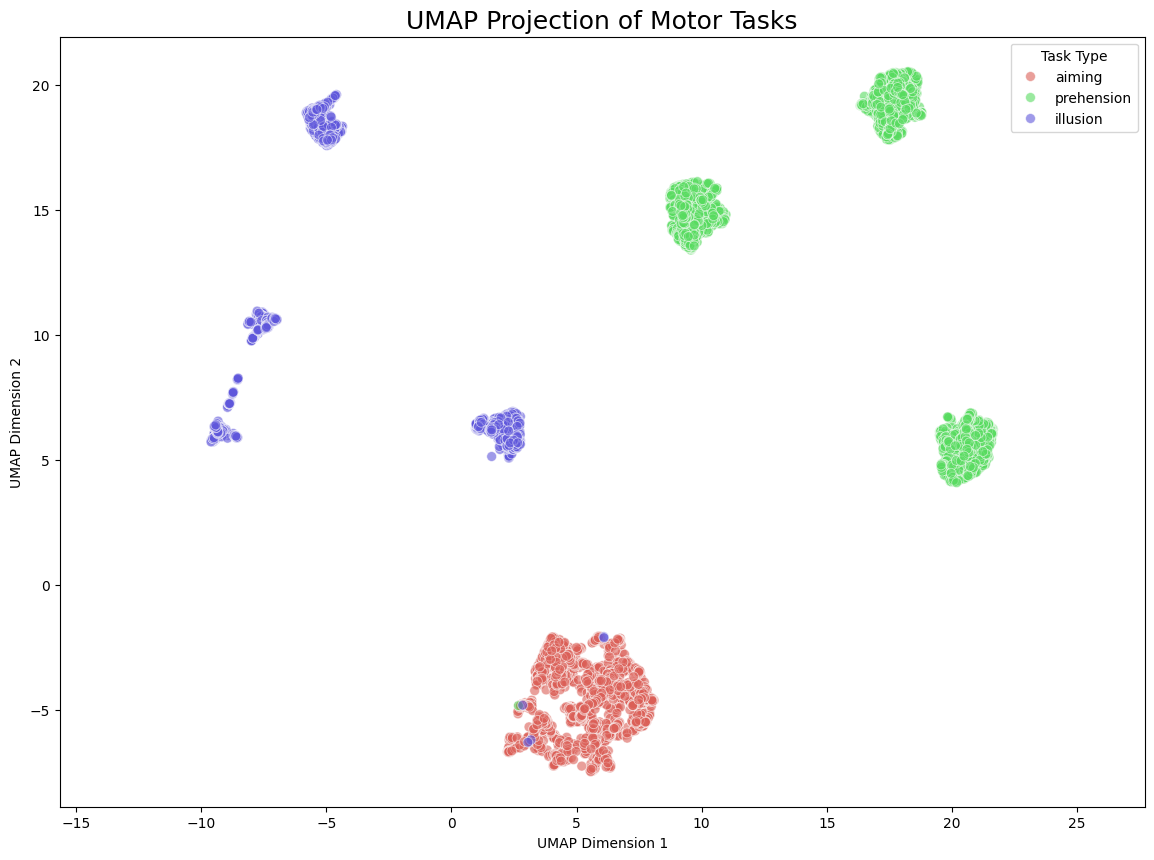

In [9]:
# 2. Create the plot
plt.figure(figsize=(14, 10))
sns.scatterplot(
    x=embedding[:, 0],
    y=embedding[:, 1],
    hue=y,
    palette=sns.color_palette("hls", 3),
    s=50,
    alpha=0.6
)

plt.gca().set_aspect("equal", "datalim")
plt.title("UMAP Projection of Motor Tasks", fontsize=18)
plt.xlabel('UMAP Dimension 1')
plt.ylabel("UMAP Dimension 2")
plt.legend(title="Task Type")
plt.show()

# Phase 3: High Performance Classification with XGBoost and Optuna

In [26]:
# Encode target labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)
num_class = len(np.unique(y_encoded))

# Define the objective function for Optuna
def objective(trial):
    param = {
        'objective': 'multi:softprob',
        'num_class': num_class,
        'eval_metric': 'mlogloss',
        'booster': 'gbtree',
        'tree_method': 'gpu_hist',              
        'predictor': 'gpu_predictor',           
        'n_estimators': trial.suggest_int('n_estimators', 200, 1000),
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'gamma': trial.suggest_float('gamma', 0, 5),
        'lambda': trial.suggest_float('lambda', 1, 10),
        'alpha': trial.suggest_float('alpha', 0, 5),
        'verbosity': 0,
        'seed': 123
    }

    model = xgb.XGBClassifier(**param)

    # Using StratifiedKFold for balance class representation in folds during training
    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=123)
    scores = []
    for train_idx, val_idx in skf.split(X_scaled, y_encoded):
        X_train, X_val = X_scaled[train_idx], X_scaled[val_idx]
        y_train, y_val = y_encoded[train_idx], y_encoded[val_idx]

        model.fit(X_train, y_train, verbose=False)
        preds = model.predict(X_val)
        scores.append(accuracy_score(y_val, preds))

    return np.mean(scores)


In [27]:
# Create an Optuna Study
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50)

print(f"Best trail score: {study.best_value}")
print("Best hyperparameters: ", study.best_params)

[I 2025-06-23 17:46:41,096] A new study created in memory with name: no-name-f20bee78-deb6-44e9-8b3f-c8064644b48c
[I 2025-06-23 17:46:45,292] Trial 0 finished with value: 1.0 and parameters: {'n_estimators': 635, 'max_depth': 6, 'learning_rate': 0.07749113091269066, 'subsample': 0.7419812531258594, 'colsample_bytree': 0.7197921323408981, 'gamma': 3.5260227345217516, 'lambda': 4.977481662998703, 'alpha': 4.27932820316603}. Best is trial 0 with value: 1.0.
[I 2025-06-23 17:46:51,041] Trial 1 finished with value: 0.999854184893555 and parameters: {'n_estimators': 920, 'max_depth': 4, 'learning_rate': 0.07248109805437712, 'subsample': 0.9006960565680273, 'colsample_bytree': 0.9559236824174668, 'gamma': 2.9024027722107144, 'lambda': 8.405076663841193, 'alpha': 1.624593233312463}. Best is trial 0 with value: 1.0.
[I 2025-06-23 17:46:54,503] Trial 2 finished with value: 1.0 and parameters: {'n_estimators': 569, 'max_depth': 3, 'learning_rate': 0.17535404366628687, 'subsample': 0.5660164221090

Best trail score: 1.0
Best hyperparameters:  {'n_estimators': 635, 'max_depth': 6, 'learning_rate': 0.07749113091269066, 'subsample': 0.7419812531258594, 'colsample_bytree': 0.7197921323408981, 'gamma': 3.5260227345217516, 'lambda': 4.977481662998703, 'alpha': 4.27932820316603}


In [28]:
# Train final model with best params and evaluate with GroupKFold
best_params = study.best_params
best_params.update({'objective': 'multi:softmax', 'num_class': num_class, 'use_label_encoder': False, 'seed': 123})
final_model = xgb.XGBClassifier(**best_params)

# Proper evaluation using GroupKFold
group_kfold = GroupKFold(n_splits=5)
cv_scores = cross_val_score(final_model, X_scaled, y_encoded, cv=group_kfold, groups=groups)

print(f"\nFinal Model Cross Validation accuracy scores (GroupKFold): {cv_scores}")
print(f"Mean CV Accuracy: {np.mean(cv_scores):.4f} (+/- {np.std(cv_scores):.4f})")

final_model.fit(X_scaled, y_encoded)

c:\CourseWork\Dissertation Classifying grip strategies using machine learning\.venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [17:49:59] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\CourseWork\Dissertation Classifying grip strategies using machine learning\.venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [17:50:00] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\CourseWork\Dissertation Classifying grip strategies using machine learning\.venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [17:50:01] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\CourseWork\Dissertation Classifying grip strategi


Final Model Cross Validation accuracy scores (GroupKFold): [1. 1. 1. 1. 1.]
Mean CV Accuracy: 1.0000 (+/- 0.0000)


c:\CourseWork\Dissertation Classifying grip strategies using machine learning\.venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [17:50:05] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,objective,'multi:softmax'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.7197921323408981
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


# Phase 4: Deep Model Interpretation with SHAP

<class 'numpy.ndarray'>
(6857, 239, 3)


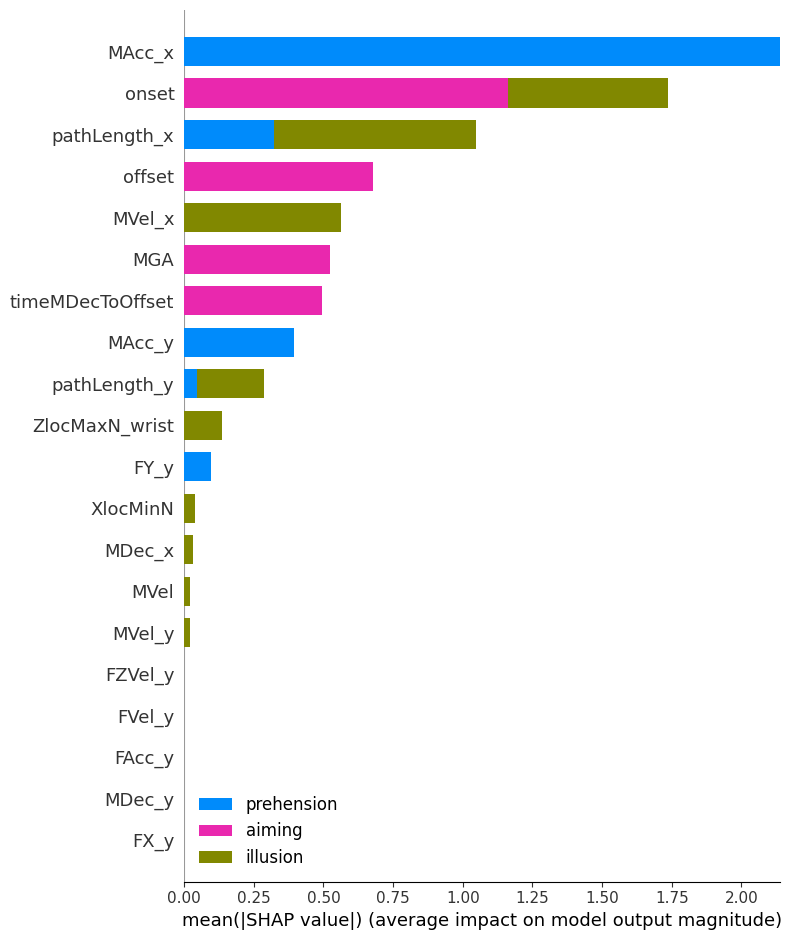

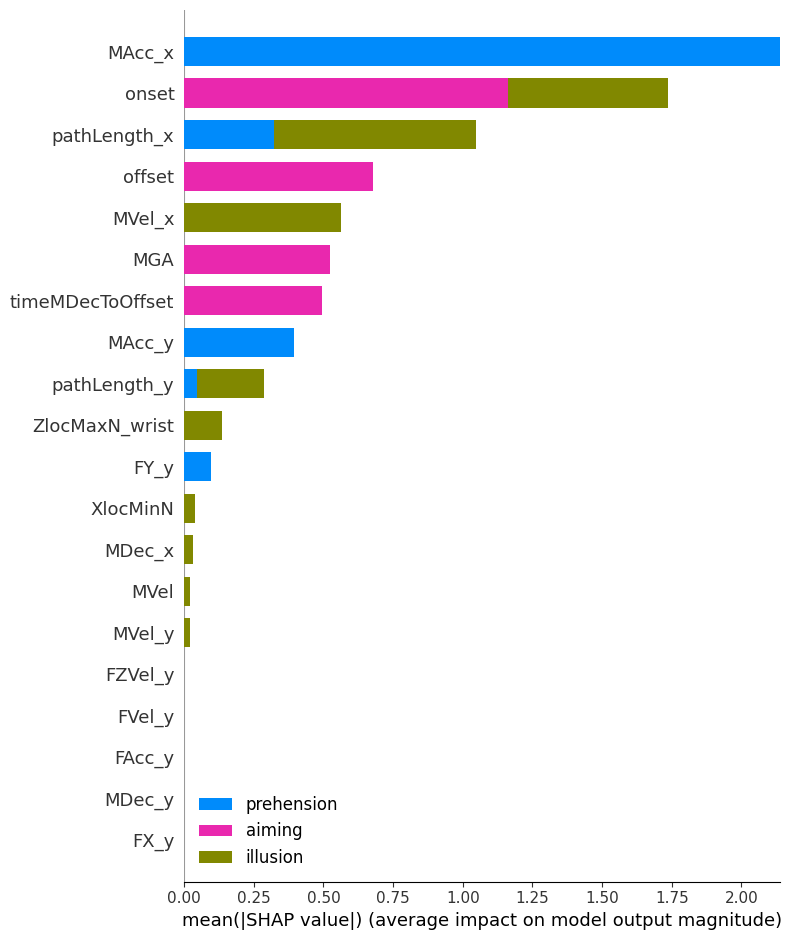

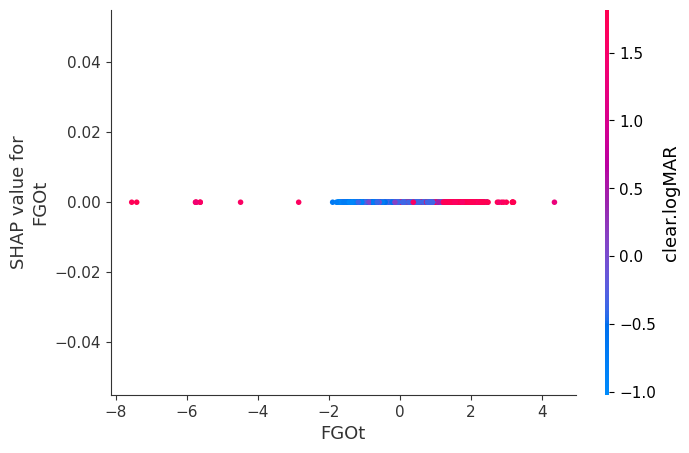

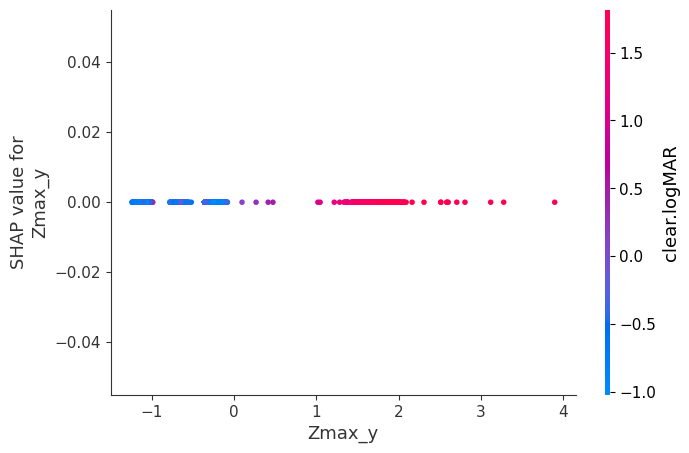

In [34]:
explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_scaled)

print(type(shap_values))
print(np.shape(shap_values))

if isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
    # Convert 3D array to list of 2D arrays (per class)
    shap_values = [shap_values[:, :, i] for i in range(shap_values.shape[2])]

X_scaled_df = pd.DataFrame(X_scaled, columns=X_imputed.columns)

# Now safe to plot:
shap.summary_plot(shap_values, X_scaled_df, plot_type="bar", class_names=le.classes_)
shap.summary_plot(shap_values, X_scaled_df, class_names=le.classes_)

illusion_class_index = le.transform(['illusion'])[0]
shap.dependence_plot("FGOt", shap_values[illusion_class_index], X_scaled_df)

prehension_class_index = le.transform(['prehension'])[0]
shap.dependence_plot("Zmax_y", shap_values[prehension_class_index], X_scaled_df)
